<div style="
    background:
        radial-gradient(circle at 90% 15%, rgba(45, 212, 191, 0.18) 0%, transparent 28%),
        radial-gradient(circle at 8% 85%, rgba(16, 185, 129, 0.12) 0%, transparent 30%),
        linear-gradient(135deg, #F0FDFA 0%, #ECFDF5 50%, #F8FAFC 100%);
    border-radius: 20px;
    padding: 32px;
    margin: 20px 0;
    text-align: center;
    border: 1px solid #CCFBF1;
">

<div style="
    font-size: 13px;
    letter-spacing: 2px;
    font-weight: 700;
    color: #0F766E;
">
BINX TECH • AI & MACHINE LEARNING
</div>

<div style="
    font-size: 32px;
    font-weight: 800;
    color: #064E3B;
    margin-top: 12px;
">
🫀 Heart Disease Clustering Analysis
</div>

<div style="
    font-size: 18px;
    color: #0F766E;
    margin-top: 8px;
    font-weight: 600;
">
Week 5 • Day 2 — DBSCAN & Hierarchical Clustering
</div>

<div style="
    max-width: 850px;
    margin: 20px auto 0 auto;
    padding: 18px 22px;
    background: rgba(255,255,255,0.75);
    border-radius: 14px;
    color: #334155;
    font-size: 16px;
    line-height: 1.8;
">

Today, we will apply <strong style="color:#0F766E;">
DBSCAN</strong> and <strong style="color:#0F766E;">
Hierarchical Clustering</strong> to the Heart Disease dataset.

<br>

The goal is to explore whether patients can be grouped according to
similar patterns in their medical measurements, while also identifying
possible noise or unusual observations.

</div>

<div style="
    margin-top: 20px;
    display: inline-block;
    background: #0F766E;
    color: white;
    padding: 9px 20px;
    border-radius: 25px;
    font-size: 13px;
    font-weight: 700;
">
DBSCAN • HIERARCHICAL CLUSTERING
</div>

</div>

<div style="
    background: linear-gradient(135deg, #FFFFFF, #F0FDFA);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 24px;
    margin-top: 0;
">
📋 About the Dataset
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.9;
">
The Heart Disease dataset contains clinical measurements collected from
patients, including age, blood pressure, cholesterol, maximum heart rate,
exercise-related information, and other medical characteristics.
</p>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.9;
">
For this clustering task, we will focus on numerical medical features
because clustering algorithms calculate distances between observations.
We will standardize these features before applying the clustering methods.
</p>

<div style="
    margin-top: 16px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🎯 <strong>Today's Goal:</strong>
Compare DBSCAN and Hierarchical Clustering and determine which method
better reveals meaningful patient groups in the dataset.
</div>

</div>

<div style="
    background:
        radial-gradient(circle at 95% 10%, rgba(45,212,191,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🔹 Step 1 — Load & Explore the Dataset
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
First, we will load the Heart Disease dataset and perform a brief
exploration to understand its structure, size, features, and data quality
before applying clustering algorithms.
</p>

<p style="
    color: #047857;
    font-size: 16px;
    line-height: 1.8;
">
🎯 <strong>Goal:</strong> Understand the dataset and identify the numerical
features that will be used for clustering.
</p>

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Load the dataset
df = pd.read_csv("heart_disease_uci.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
# Display dataset information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [3]:
# Check missing values

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

In [4]:
# Select numerical features for clustering

features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

X = df[features].copy()

display(X.head())

,age,trestbps,chol,thalch,oldpeak,ca
0,63,145.0,233.0,150.0,2.3,0.0
1,67,160.0,286.0,108.0,1.5,3.0
2,67,120.0,229.0,129.0,2.6,2.0
3,37,130.0,250.0,187.0,3.5,0.0
4,41,130.0,204.0,172.0,1.4,0.0


In [5]:
# Summary statistics

display(X.describe())

,age,trestbps,chol,thalch,oldpeak,ca
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000


<div style="
    background:
        radial-gradient(circle at 8% 20%, rgba(16,185,129,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
⚙️ Step 2 — Data Preprocessing & Scaling
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
Before applying clustering, we need to prepare the numerical features.
Missing values will be handled using the median, and the features will be
standardized so that variables with larger numerical ranges do not dominate
the distance calculations.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
📏 <strong>Why scaling?</strong>
DBSCAN and Hierarchical Clustering rely on distances between data points,
so putting all features on a comparable scale is important.
</div>

</div>

In [6]:
# Check missing values in the selected features

print("Missing values before preprocessing:")

display(X.isnull().sum())

Missing values before preprocessing:


age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
dtype: int64

In [7]:
# Fill missing numerical values with the median

X_clean = X.copy()

X_clean = X_clean.fillna(X_clean.median())

print("Missing values after preprocessing:")

display(X_clean.isnull().sum())

Missing values after preprocessing:


age         0
trestbps    0
chol        0
thalch      0
oldpeak     0
ca          0
dtype: int64

In [8]:
# Standardize the numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (920, 6)


In [9]:
# Create a DataFrame for the scaled features

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

display(X_scaled_df.head())

,age,trestbps,chol,thalch,oldpeak,ca
0,1.007386,0.705176,0.303643,0.489727,1.368109,-0.361400
1,1.432034,1.518569,0.789967,-1.181478,0.611589,4.411152
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,2.820301
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,-0.361400
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,-0.361400


In [10]:
# Verify the mean and standard deviation after scaling

print("Means after scaling:")
display(X_scaled_df.mean().round(2))

print("Standard deviations after scaling:")
display(X_scaled_df.std().round(2))

Means after scaling:


age         0.0
trestbps    0.0
chol       -0.0
thalch     -0.0
oldpeak    -0.0
ca          0.0
dtype: float64

Standard deviations after scaling:


age         1.0
trestbps    1.0
chol        1.0
thalch      1.0
oldpeak     1.0
ca          1.0
dtype: float64

<div style="
    background:
        radial-gradient(circle at 92% 15%, rgba(45,212,191,0.14), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🔵 Step 3 — Apply DBSCAN
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
Now we will apply DBSCAN to the standardized medical features.
Unlike K-Means, DBSCAN does not require us to specify the number of
clusters in advance and can identify observations that behave like
noise or outliers.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🎯 <strong>Goal:</strong>
Identify patient groups based on density and determine how many
observations are classified as noise.
</div>

</div>

In [11]:
# Apply DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN completed successfully!")

DBSCAN completed successfully!


In [13]:
# Count clusters and noise points

n_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 5
Number of noise points: 375


In [14]:
# Display the number of observations in each cluster

cluster_counts = df["DBSCAN_Cluster"].value_counts().sort_index()

display(cluster_counts)

DBSCAN_Cluster
-1    375
 0    427
 1      8
 2     27
 3     78
 4      5
Name: count, dtype: int64

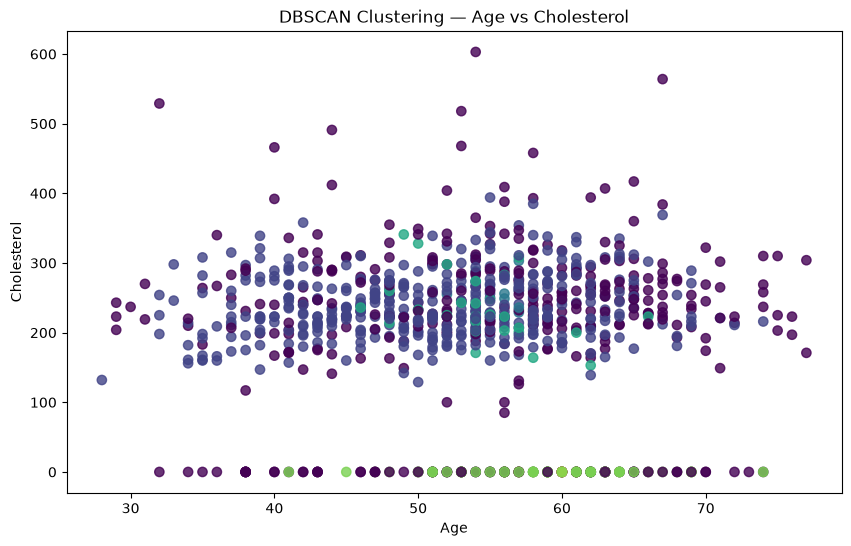

In [15]:
# Visualize DBSCAN clusters using two features

plt.figure(figsize=(10, 6))

plt.scatter(
    X_clean["age"],
    X_clean["chol"],
    c=dbscan_labels,
    cmap="viridis",
    s=45,
    alpha=0.8
)

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("DBSCAN Clustering — Age vs Cholesterol")

plt.show()

In [16]:
# Display observations classified as noise

noise_points = df[df["DBSCAN_Cluster"] == -1]

print("Number of noise points:", len(noise_points))

display(
    noise_points[
        ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "DBSCAN_Cluster"]
    ].head(10)
)

Number of noise points: 375


,age,trestbps,chol,thalch,oldpeak,ca,DBSCAN_Cluster
1,67,160.0,286.0,108.0,1.5,3.0,-1
2,67,120.0,229.0,129.0,2.6,2.0,-1
3,37,130.0,250.0,187.0,3.5,0.0,-1
4,41,130.0,204.0,172.0,1.4,0.0,-1
5,56,120.0,236.0,178.0,0.8,0.0,-1
6,62,140.0,268.0,160.0,3.6,2.0,-1
8,63,130.0,254.0,147.0,1.4,1.0,-1
14,52,172.0,199.0,162.0,0.5,0.0,-1
20,64,110.0,211.0,144.0,1.8,0.0,-1
23,58,132.0,224.0,173.0,3.2,2.0,-1


<div style="
    background:
        radial-gradient(circle at 8% 85%, rgba(20,184,166,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 12px 0;
">
🌿 Step 4 — Hierarchical Clustering
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
In this step, we will apply Hierarchical Clustering to the same
standardized patient data. The main goal is to build a dendrogram
that shows how observations are progressively grouped together.
</p>

<div style="
    margin-top: 15px;
    padding: 14px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
">
🌱 <strong>Goal:</strong>
Visualize the hierarchical structure of the data and choose a
reasonable number of clusters from the dendrogram.
</div>

</div>

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Build the hierarchical clustering structure

Z = linkage(
    X_scaled,
    method="ward"
)

print("Linkage matrix shape:", Z.shape)

Linkage matrix shape: (919, 4)


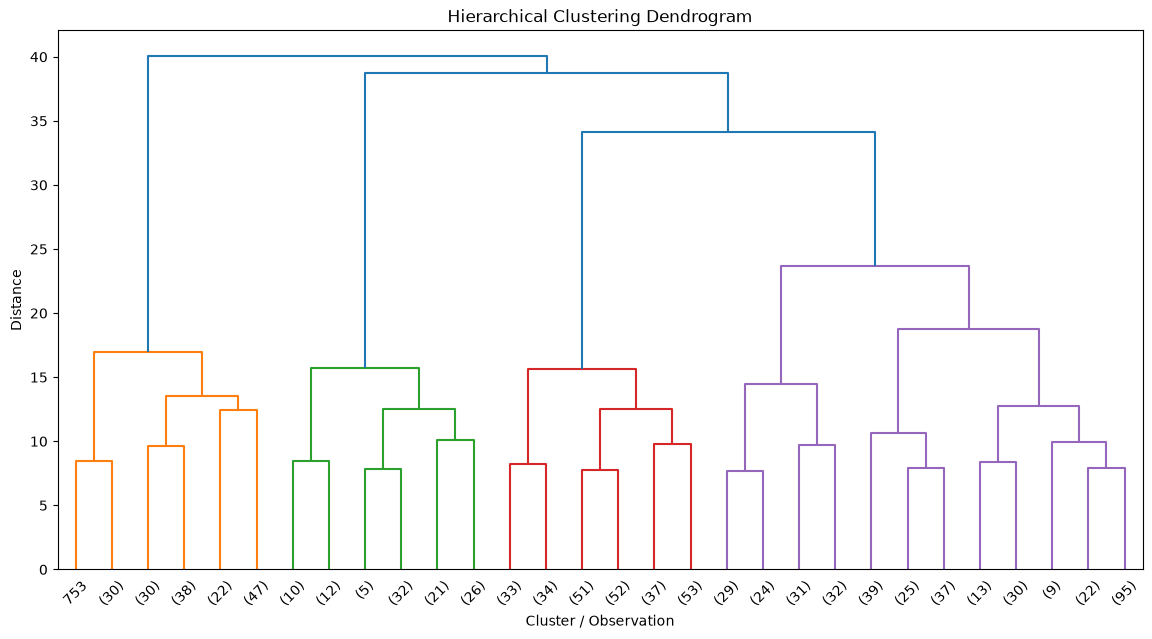

In [18]:
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Observation")
plt.ylabel("Distance")

plt.show()

In [19]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram to create 4 clusters

hierarchical_labels = fcluster(
    Z,
    t=4,
    criterion="maxclust"
)

df["Hierarchical_Cluster"] = hierarchical_labels

print("Number of clusters:", len(set(hierarchical_labels)))

display(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Number of clusters: 4


Hierarchical_Cluster
1    168
2    106
3    260
4    386
Name: count, dtype: int64

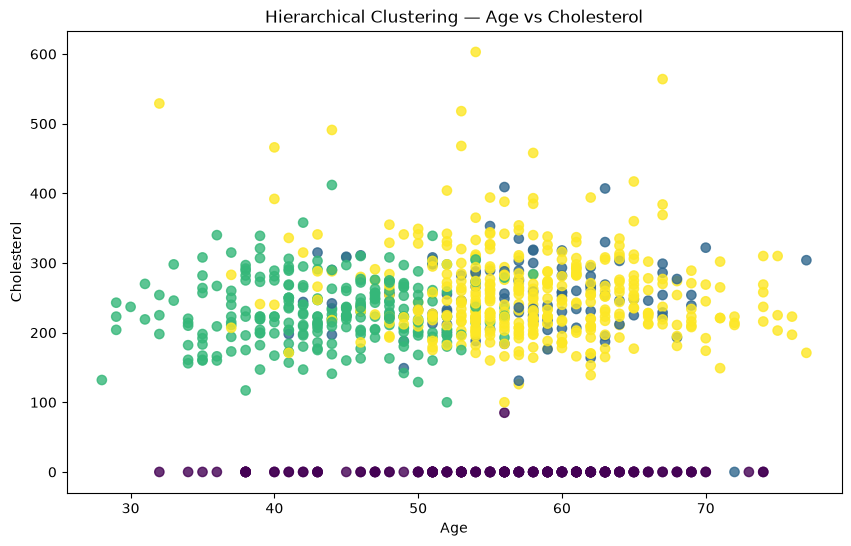

In [20]:
# Visualize the hierarchical clustering results

plt.figure(figsize=(10, 6))

plt.scatter(
    X_clean["age"],
    X_clean["chol"],
    c=hierarchical_labels,
    cmap="viridis",
    s=45,
    alpha=0.8
)

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Hierarchical Clustering — Age vs Cholesterol")

plt.show()


<div style="
    background:
        radial-gradient(circle at 90% 20%, rgba(20,184,166,0.12), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<h2 style="color:#065F46; font-size:25px; margin:0 0 12px 0;">
🔬 Step 5 — Compare the Clustering Methods
</h2>

<p style="color:#475569; font-size:17px; line-height:1.8;">
Now we will compare K-Means, DBSCAN, and Hierarchical Clustering
using the same patient dataset. The comparison will help us understand
how each algorithm groups the observations and how their results differ.
</p>

<div style="
    margin-top:15px;
    padding:14px 18px;
    background:#ECFDF5;
    border-radius:10px;
    color:#047857;
    font-size:16px;
">
🩺 <strong>Goal:</strong>
Determine which clustering method provides the most meaningful
representation of the patient data.
</div>

</div>

In [21]:
from sklearn.cluster import KMeans

# Apply K-Means using the same scaled data

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means clusters:", len(set(kmeans_labels)))

display(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

K-Means clusters: 4


KMeans_Cluster
0    356
1    333
2     67
3    164
Name: count, dtype: int64

In [22]:
# Compare the number of observations assigned to each cluster

comparison = pd.DataFrame({
    "K-Means": pd.Series(kmeans_labels).value_counts().sort_index(),
    "DBSCAN": pd.Series(dbscan_labels).value_counts().sort_index(),
    "Hierarchical": pd.Series(hierarchical_labels).value_counts().sort_index()
})

display(comparison.fillna(0).astype(int))

,K-Means,DBSCAN,Hierarchical
-1,0,375,0
0,356,427,0
1,333,8,168
2,67,27,106
3,164,78,260
4,0,5,386


In [23]:
from sklearn.decomposition import PCA

# Reduce the scaled data to 2 dimensions for visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.28545104 0.21976313]


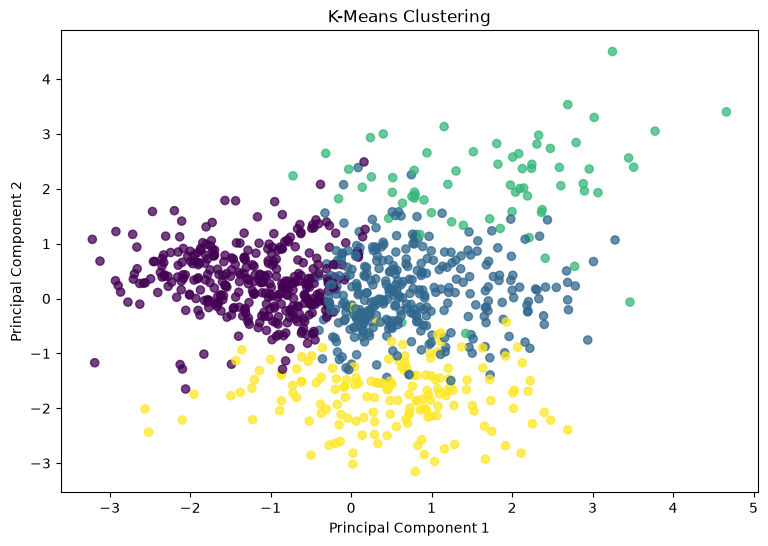

In [24]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

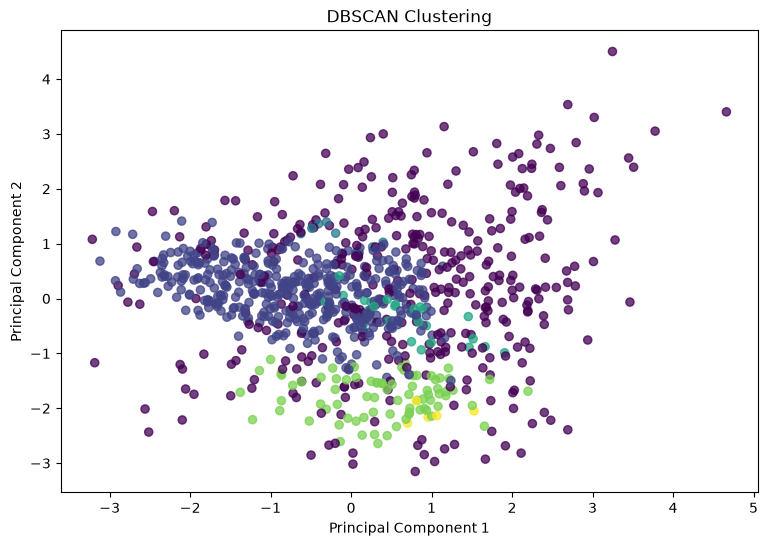

In [25]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("DBSCAN Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

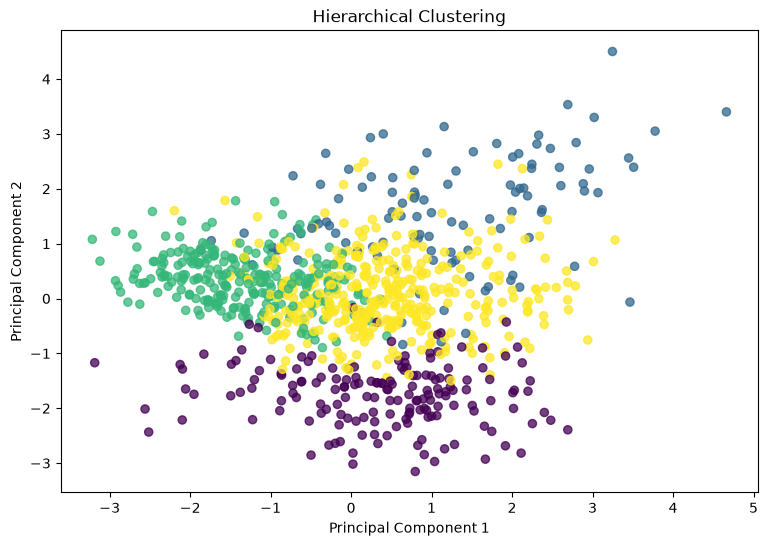

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [27]:
# ==========================================
# Clustering Results Summary
# ==========================================

print("=" * 60)
print("CLUSTERING RESULTS SUMMARY")
print("=" * 60)


# -------------------------
# 1. DBSCAN
# -------------------------

dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

dbscan_noise = (dbscan_labels == -1).sum()

print("\n--- DBSCAN ---")
print("Number of clusters:", dbscan_clusters)
print("Number of noise points:", dbscan_noise)

print("\nDBSCAN cluster sizes:")
print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)


# -------------------------
# 2. Hierarchical
# -------------------------

hierarchical_clusters = len(
    set(hierarchical_labels)
)

print("\n--- HIERARCHICAL CLUSTERING ---")
print("Number of clusters:", hierarchical_clusters)

print("\nHierarchical cluster sizes:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)


# -------------------------
# 3. K-Means
# -------------------------

print("\n--- K-MEANS ---")

if "kmeans_labels" in globals():

    kmeans_clusters = len(
        set(kmeans_labels)
    )

    print("Number of clusters:", kmeans_clusters)

    print("\nK-Means cluster sizes:")
    print(
        pd.Series(kmeans_labels)
        .value_counts()
        .sort_index()
    )

else:
    print("K-Means labels not found.")


# -------------------------
# 4. Dataset Information
# -------------------------

print("\n--- DATASET ---")
print("Total observations:", len(df))
print("Number of features used:", X_scaled.shape[1])

print("\n" + "=" * 60)

CLUSTERING RESULTS SUMMARY

--- DBSCAN ---
Number of clusters: 5
Number of noise points: 375

DBSCAN cluster sizes:
-1    375
 0    427
 1      8
 2     27
 3     78
 4      5
Name: count, dtype: int64

--- HIERARCHICAL CLUSTERING ---
Number of clusters: 4

Hierarchical cluster sizes:
1    168
2    106
3    260
4    386
Name: count, dtype: int64

--- K-MEANS ---
Number of clusters: 4

K-Means cluster sizes:
0    356
1    333
2     67
3    164
Name: count, dtype: int64

--- DATASET ---
Total observations: 920
Number of features used: 6



In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

print("=" * 60)
print("FINAL CLUSTERING COMPARISON")
print("=" * 60)

# ============================================================
# 1. K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("\n--- K-MEANS ---")
print("Number of clusters:", len(set(kmeans_labels)))
print("Silhouette Score:", round(kmeans_silhouette, 4))

print("\nK-Means cluster sizes:")
print(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)


# ============================================================
# 2. DBSCAN
# ============================================================

dbscan_silhouette = None

# Remove noise points before calculating silhouette score
dbscan_mask = dbscan_labels != -1

if len(set(dbscan_labels[dbscan_mask])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )

print("\n--- DBSCAN ---")
print(
    "Number of clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of noise points:",
    np.sum(dbscan_labels == -1)
)

if dbscan_silhouette is not None:
    print(
        "Silhouette Score (excluding noise):",
        round(dbscan_silhouette, 4)
    )

print("\nDBSCAN cluster sizes:")
print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)


# ============================================================
# 3. HIERARCHICAL CLUSTERING
# ============================================================

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("\n--- HIERARCHICAL CLUSTERING ---")
print(
    "Number of clusters:",
    len(set(hierarchical_labels))
)

print(
    "Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

print("\nHierarchical cluster sizes:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)


# ============================================================
# 4. FINAL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Method": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Clusters": [
        len(set(kmeans_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        len(set(hierarchical_labels))
    ],
    "Noise Points": [
        0,
        np.sum(dbscan_labels == -1),
        0
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette,
        hierarchical_silhouette
    ]
})

print("\n" + "=" * 60)
print("COMPARISON TABLE")
print("=" * 60)

display(comparison.round(4))

FINAL CLUSTERING COMPARISON

--- K-MEANS ---
Number of clusters: 4
Silhouette Score: 0.2241

K-Means cluster sizes:
0    356
1    333
2     67
3    164
Name: count, dtype: int64

--- DBSCAN ---
Number of clusters: 5
Number of noise points: 375
Silhouette Score (excluding noise): 0.0898

DBSCAN cluster sizes:
-1    375
 0    427
 1      8
 2     27
 3     78
 4      5
Name: count, dtype: int64

--- HIERARCHICAL CLUSTERING ---
Number of clusters: 4
Silhouette Score: 0.1783

Hierarchical cluster sizes:
1    168
2    106
3    260
4    386
Name: count, dtype: int64

COMPARISON TABLE


,Method,Clusters,Noise Points,Silhouette Score
0,K-Means,4,0,0.2241
1,DBSCAN,5,375,0.0898
2,Hierarchical,4,0,0.1783


<div style="
    background:
        radial-gradient(circle at 90% 15%, rgba(20,184,166,0.13), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 24px 28px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
    box-shadow: 0 4px 14px rgba(6,95,70,0.08);
">

<h2 style="
    color: #065F46;
    font-size: 25px;
    margin: 0 0 14px 0;
">
📊 Final Clustering Comparison
</h2>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">
We compared three clustering methods on the same standardized
patient dataset: K-Means, DBSCAN, and Hierarchical Clustering.
The models were evaluated using the Silhouette Score.
</p>

<div style="
    background: #FFFFFF;
    border-left: 5px solid #10B981;
    border-radius: 10px;
    padding: 14px 18px;
    margin: 14px 0;
    color: #334155;
    font-size: 16px;
    line-height: 1.8;
">

<strong style="color:#047857;">🏆 Best Method: K-Means</strong>
<br><br>

K-Means achieved the highest Silhouette Score of
<strong>0.2241</strong>, compared with <strong>0.1783</strong>
for Hierarchical Clustering and <strong>0.0898</strong> for DBSCAN.

</div>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">

DBSCAN identified <strong>5 clusters</strong>, but it also classified
<strong>375 observations as noise</strong>. This represents approximately
<strong>40.8%</strong> of the dataset, which is a relatively large
portion of the observations. Its lower Silhouette Score also indicates
weaker cluster separation for this dataset.

</p>

<p style="
    color: #475569;
    font-size: 17px;
    line-height: 1.8;
">

Hierarchical Clustering produced <strong>4 clusters</strong> and achieved
a Silhouette Score of <strong>0.1783</strong>. Although it performed
reasonably well, its score was lower than K-Means.

</p>

<div style="
    margin-top: 16px;
    padding: 15px 18px;
    background: #ECFDF5;
    border-radius: 10px;
    color: #047857;
    font-size: 16px;
    line-height: 1.8;
">

<strong>Conclusion:</strong>
Based on the Silhouette Scores and cluster distributions,
<strong>K-Means provides the most suitable clustering result
for this dataset.</strong>

</div>

</div>